#  DQN

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 
* Саттон Р.	С.,	Барто Э. Дж. Обучение с подкреплением: Введение. 2-е изд.
* https://en.wikipedia.org/wiki/Q-learning
* https://pythonprogramming.net/q-learning-reinforcement-learning-python-tutorial/
* https://pytorch.org/tutorials/intermediate/reinforcement_q_learning.html
* https://github.com/pylSER/Deep-Reinforcement-learning-Mountain-Car/tree/master
* https://valohai.com/blog/reinforcement-learning-tutorial-basic-deep-q-learning/

## Задачи для совместного разбора

1\. Обсудите основные отличия DQN от классических вариантов Q-learning.

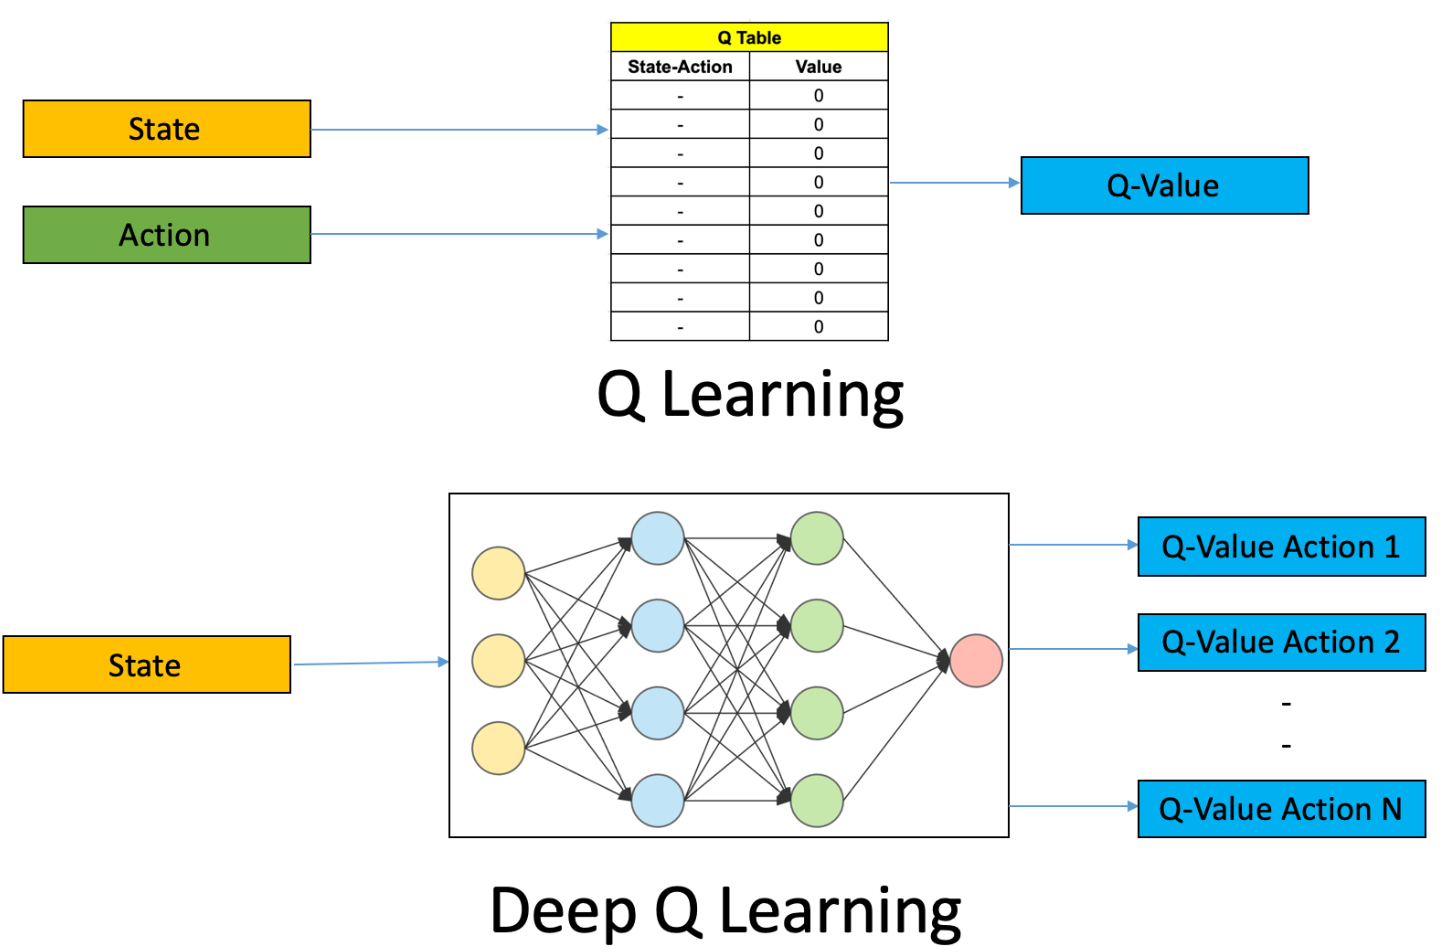

<img src="https://valohai.com/blog/reinforcement-learning-tutorial-part-1-q-learning/image4.png" width="500">
<img src="https://valohai.com/blog/reinforcement-learning-tutorial-basic-deep-q-learning/4.png" width="500">


## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Допишите класс `ReplayMemory` для хранения переходов между состояниями.

- [ ] Проверено на семинаре

In [1]:
import random
from collections import namedtuple, deque
from dataclasses import dataclass
import torch as th
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
from gymnasium.wrappers import TransformObservation
import numpy as np

In [2]:
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward', 'done'))

class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, *args):
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)



<p class="task" id="2"></p>

2\. Допишите класс `DQN` для моделирования Q-функции. 

- [ ] Проверено на семинаре

In [3]:
import torch.nn as nn

class DQN(nn.Module):
    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(n_observations, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions)
        )

    def forward(self, x):
        return self.model(x)

<p class="task" id="3"></p>

3\. Допишите классы `PolicyConfig` для настроек политики агента и `Policy` для реализации политики. 

- [ ] Проверено на семинаре

In [4]:
from dataclasses import dataclass

@dataclass
class PolicyConfig:
    n_observations: int
    n_actions: int
    device: str
    epsilon_start: float
    epsilon_final: float
    epsilon_decay: float

In [5]:
import torch as th
class Policy:
    def __init__(self, config: PolicyConfig):
        self.config = config
        self.policy_network = DQN(config.n_observations, config.n_actions).to(config.device)
        self.target_network = DQN(config.n_observations, config.n_actions).to(config.device)
        self.epsilon = config.epsilon_start
        self.sync_models()

    def sync_models(self):
        self.target_network.load_state_dict(self.policy_network.state_dict())

    def get_action(self, state: th.Tensor):
        if random.random() < self.epsilon:
            return random.randint(0, self.config.n_actions - 1)
        with th.no_grad():
            return self.policy_network(state).argmax().item()

    def update_epsilon(self):
        self.epsilon = max(
            self.config.epsilon_final,
            self.epsilon * self.config.epsilon_decay
        )

    def save(self, path: str):
        th.save(self.policy_network.state_dict(), f"{path}_policy.pth")
        th.save(self.target_network.state_dict(), f"{path}_target.pth")

    def load(self, path: str):
        self.policy_network.load_state_dict(th.load(f"{path}_policy.pth", map_location=self.policy_cfg.device))
        self.target_network.load_state_dict(th.load(f"{path}_target.pth", map_location=self.policy_cfg.device))

<p class="task" id="4"></p>

4\. Напишите функцию `plot_metrics`, которая будет использоваться для визуализации процесса обучения: суммарной награды за каждый эпизод и максимальное значение x-координаты машины за эпизод. Для реализации можете воспользоваться `tensorboard` или любым другим удобным инструментом. 

- [ ] Проверено на семинаре

In [6]:
def plot_metrics(episode_rewards, max_x_coords, success_rates, interval=100):
        def compute_averages(values, interval):
            values = [v.cpu().item() if isinstance(v, th.Tensor) else v for v in values]
            return [np.mean(values[i:i + interval]) for i in range(0, len(values), interval)]
        avg_rewards = compute_averages(episode_rewards, interval)
        avg_max_x = compute_averages(max_x_coords, interval)
        avg_success_rates = compute_averages(success_rates, interval)
        plt.figure(figsize=(18, 5))
        plt.subplot(1, 3, 1)
        plt.plot(avg_rewards, label=f'Average Reward (per {interval} episodes)')
        plt.xlabel(f'Interval ({interval} episodes)')
        plt.ylabel('Average Total Reward')
        plt.legend()
    
        plt.subplot(1, 3, 2)
        plt.plot(avg_max_x, label=f'Average Max X Coord (per {interval} episodes)', color='orange')
        plt.xlabel(f'Interval ({interval} episodes)')
        plt.ylabel('Average Max X Coord')
        plt.legend()
    
        plt.subplot(1, 3, 3)
        plt.plot(avg_success_rates, label=f'Average Success Rate (per {interval} episodes)', color='green')
        plt.xlabel(f'Interval ({interval} episodes)')
        plt.ylabel('Average Success Rate')
        plt.legend()
    
        plt.tight_layout()
        plt.show()

<p class="task" id="5"></p>

5\. Допишите классы `TrainConfig` для настроек обучения и `Trainer` для реализации процесса обучения. 

- [ ] Проверено на семинаре

In [7]:
@dataclass
class TrainConfig:
    gamma: float
    learning_rate: float
    num_episodes: int
    batch_size: int
    sync_frequency: int
    max_steps_per_episode: int

In [9]:
class Trainer:
    def __init__(self, env: gym.Env, train_config: TrainConfig, policy: Policy):
        self.env = env
        self.config = train_config
        self.policy = policy
        self.memory = ReplayMemory(100_000)
        self.optimizer = optim.Adam(self.policy.policy_network.parameters(), lr=self.config.learning_rate)
        self.criterion = nn.MSELoss()
        self.best_reward = -float('inf')  # Хранение наилучшей награды
        self.episode_rewards = []
        self.max_x_coords = []
        self.success_rates = []

    def train(self):
        for episode in tqdm(range(self.config.num_episodes), desc="Training", unit="episode"):
            start_state, _ = self.env.reset()
            start_state = (
                start_state.clone().detach().to(self.policy.config.device).unsqueeze(0)
                if isinstance(start_state, th.Tensor)
                else th.tensor(start_state, dtype=th.float32, device=self.policy.config.device).unsqueeze(0)
            )

            total_reward, max_x = self.run_episode(start_state)

            self.episode_rewards.append(total_reward)
            self.max_x_coords.append(max_x)
            self.success_rates.append(1 if total_reward > -200 else 0)

            if total_reward > self.best_reward:
                self.best_reward = total_reward
                self.save_model()

            self.policy.update_epsilon()

            # Синхронизация моделей
            if episode % self.config.sync_frequency == 0:
                self.policy.sync_models()

    def run_episode(self, start_state: th.Tensor):
        state = start_state
        total_reward = 0
        max_x = -float('inf')

        for step in range(self.config.max_steps_per_episode):
            action = self.policy.get_action(state)
            next_state, reward, terminated, truncated, _ = self.env.step(action)
            done = terminated or truncated

            next_state_tensor = (
                next_state.clone().detach().to(self.policy.config.device).unsqueeze(0)
                if isinstance(next_state, th.Tensor)
                else th.tensor(next_state, dtype=th.float32, device=self.policy.config.device).unsqueeze(0)
            )

            self.memory.push(state, action, next_state_tensor, reward, done)

            state = next_state_tensor
            total_reward += reward
            max_x = max(max_x, next_state[0])

            if len(self.memory) > self.config.batch_size:
                self.generate_batch_and_fit()

            if done:
                break

        return total_reward, max_x

    def generate_batch_and_fit(self):
        if len(self.memory) < self.config.batch_size:
            return
    
        transitions = self.memory.sample(self.config.batch_size)
        batch = Transition(*zip(*transitions))
    
        states = th.cat(batch.state)
        next_states = th.cat(batch.next_state)
        actions = th.tensor(batch.action, device=self.policy.config.device).unsqueeze(1)
        rewards = th.tensor(batch.reward, device=self.policy.config.device)
        dones = th.tensor(batch.done, device=self.policy.config.device, dtype=th.float32)
    
        current_q_values = self.policy.policy_network(states).gather(1, actions).squeeze()
        next_q_values = self.policy.target_network(next_states).max(1)[0].detach()
        target_q_values = rewards + (1 - dones) * self.config.gamma * next_q_values
    
        self.fit_policy_network(states, target_q_values, actions)

    def fit_policy_network(self, X, y, actions):
        self.optimizer.zero_grad()
        # Индексация действий должна быть целочисленной
        predictions = self.policy.policy_network(X).gather(1, actions).squeeze()
        loss = self.criterion(predictions, y)
        loss.backward()
        self.optimizer.step()

    def save_model(self):
        th.save(self.policy.policy_network.state_dict(), "best_policy_network.pth")


<p class="task" id="6"></p>

6\. Настройте модель для управления машиной в окружении `MountainCar-v0`. Для преобразования векторов состояний в тензоры используйте обертку `TransformObservation`. Выведите на экран график с информацией о процессе обучения. При необходимости вставьте скриншоты этих графиков.

- [ ] Проверено на семинаре

In [10]:
env = gym.make('MountainCar-v0')
env = TransformObservation(env, lambda obs: th.tensor(obs, dtype=th.float32), observation_space=env.observation_space)

In [11]:
import matplotlib.pyplot as plt
train_config = TrainConfig(
    gamma=1,
    learning_rate=3e-4,
    num_episodes=1000,
    batch_size=256,
    sync_frequency=20,
    max_steps_per_episode=200
)

policy_config = PolicyConfig(
    n_observations=env.observation_space.shape[0],
    n_actions=env.action_space.n,
    device='cuda',
    epsilon_start=1.0,
    epsilon_final=0.00,
    epsilon_decay=0.995
)


policy = Policy(policy_config)
trainer = Trainer(env, train_config, policy)
trainer.train()


Training: 100%|██████████| 1000/1000 [06:41<00:00,  2.49episode/s]


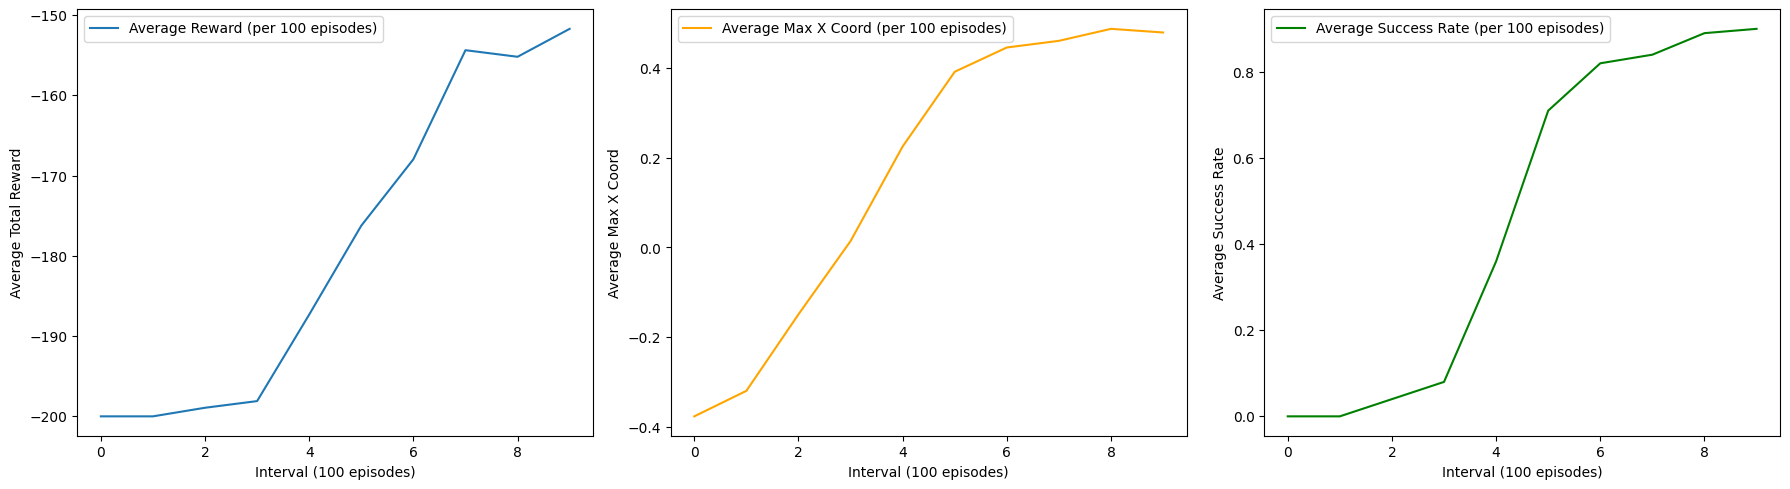

In [12]:
plot_metrics(trainer.episode_rewards, trainer.max_x_coords, trainer.success_rates, interval=100)

<p class="task" id="7"></p>

7\. Загрузите состояния моделей из файлов, которые были получены в процессе обучения. Создайте окружение и сыграйте эпизод, используя стратегию, выведенную из обученной Q-функции.

- [ ] Проверено на семинаре

In [29]:
import gym
import torch as th
import torch.nn as nn
from gym.wrappers import RecordVideo


class QPolicy:
    def __init__(self, policy_network):
        self.policy_network = policy_network
        self.policy_network.eval()

    def get_action(self, state):
        with th.no_grad():
            q_values = self.policy_network(state)
            action = th.argmax(q_values, dim=1).item()
        return action

def load_model(model_path, device, n_observations, n_actions):
    model = DQN(n_observations, n_actions)
    model.load_state_dict(th.load(model_path, map_location=device, weights_only=True))
    model.to(device)
    return model

def play_episode_with_video(env, policy, device):
    state, _ = env.reset()
    state = th.tensor(state, dtype=th.float32, device=device).unsqueeze(0)
    total_reward = 0
    done = False

    while not done:
        action = policy.get_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        state = th.tensor(next_state, dtype=th.float32, device=device).unsqueeze(0)
        total_reward += reward

    return total_reward

model_path = "best_policy_network.pth"
video_output_path = "video"
device = th.device("cuda" if th.cuda.is_available() else "cpu")

n_observations = 2
n_actions = 3

policy_network = load_model(model_path, device, n_observations, n_actions)
policy = QPolicy(policy_network)

env = gym.make("MountainCar-v0", render_mode="rgb_array")
env = RecordVideo(env, video_output_path, episode_trigger=lambda x: True)

total_reward = play_episode_with_video(env, policy, device)
print(f"Total reward from the episode: {total_reward}")

env.close()


MoviePy - Building video c:\Users\n.sedov\Documents\vscode docs\ITiABD-PM22-7-Nikolay-Sedov\DL\video\rl-video-episode-0.mp4.
MoviePy - Writing video c:\Users\n.sedov\Documents\vscode docs\ITiABD-PM22-7-Nikolay-Sedov\DL\video\rl-video-episode-0.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\n.sedov\Documents\vscode docs\ITiABD-PM22-7-Nikolay-Sedov\DL\video\rl-video-episode-0.mp4
Total reward from the episode: -200.0


In [23]:
import base64
from IPython.display import HTML

def embed_video_in_notebook(video_path):
    with open(video_path, "rb") as video_file:
        video_encoded = base64.b64encode(video_file.read()).decode("utf-8")
    video_html = f"""
    <video width="640" height="360" controls>
        <source src="data:video/mp4;base64,{video_encoded}" type="video/mp4">
        Your browser does not support the video tag.
    </video>
    """
    return HTML(video_html)


In [ ]:
video_path = "video/rl-video-episode-0.mp4"  
embed_video_in_notebook(video_path)

## Обратная связь
- [ ] Хочу получить обратную связь по решению